<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1829 | Val: 446 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 16, accumulation steps = 3 (effective batch size ≈ 48, tuned value = 48)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Using gradient accumulation: 3 micro-batches per optimizer step (effective batch size ≈ micro_batch x 3).


[DenseNet-121] Epoch   1/100 | LR: 3.44e-04 | train loss 0.7900 acc 0.622 | val loss 1.0280 acc 0.632 *


[DenseNet-121] Epoch   2/100 | LR: 3.44e-04 | train loss 0.5989 acc 0.733 | val loss 0.5514 acc 0.818 *


[DenseNet-121] Epoch   3/100 | LR: 3.44e-04 | train loss 0.4737 acc 0.793 | val loss 0.6072 acc 0.767


[DenseNet-121] Epoch   4/100 | LR: 3.44e-04 | train loss 0.4822 acc 0.800 | val loss 0.4313 acc 0.850 *


...

[DenseNet-121] Epoch  19/100 | LR: 3.44e-05 | train loss 0.0934 acc 0.961 | val loss 0.3208 acc 0.883


[DenseNet-121] Epoch  20/100 | LR: 3.44e-05 | train loss 0.0950 acc 0.955 | val loss 0.3136 acc 0.888


[DenseNet-121] Epoch  21/100 | LR: 3.44e-05 | train loss 0.0800 acc 0.966 | val loss 0.3204 acc 0.886


[DenseNet-121] Epoch  22/100 | LR: 3.44e-06 | train loss 0.0826 acc 0.964 | val loss 0.3211 acc 0.888


[DenseNet-121] Epoch  23/100 | LR: 3.44e-06 | train loss 0.0671 acc 0.974 | val loss 0.3285 acc 0.892

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 23.

[DenseNet-121] Restored best checkpoint (val loss = 0.3120)


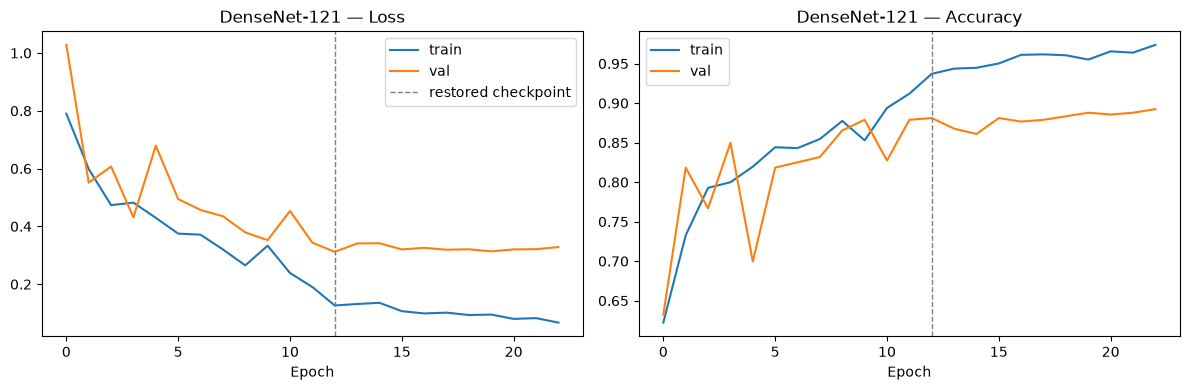

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.794


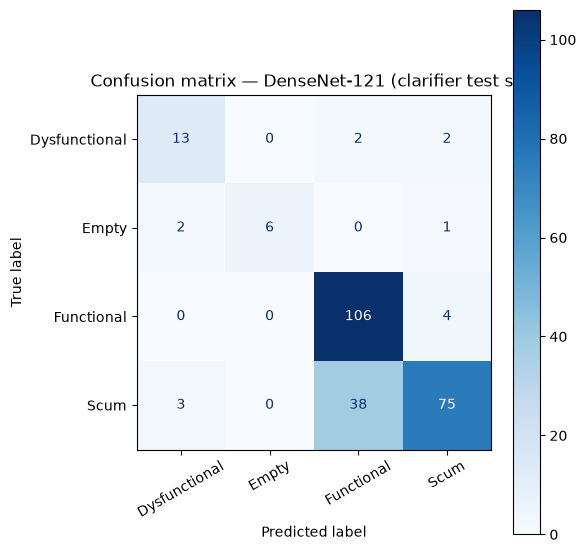

               precision    recall  f1-score   support

Dysfunctional      0.722     0.765     0.743        17
        Empty      1.000     0.667     0.800         9
   Functional      0.726     0.964     0.828       110
         Scum      0.915     0.647     0.758       116

     accuracy                          0.794       252
    macro avg      0.841     0.760     0.782       252
 weighted avg      0.822     0.794     0.789       252



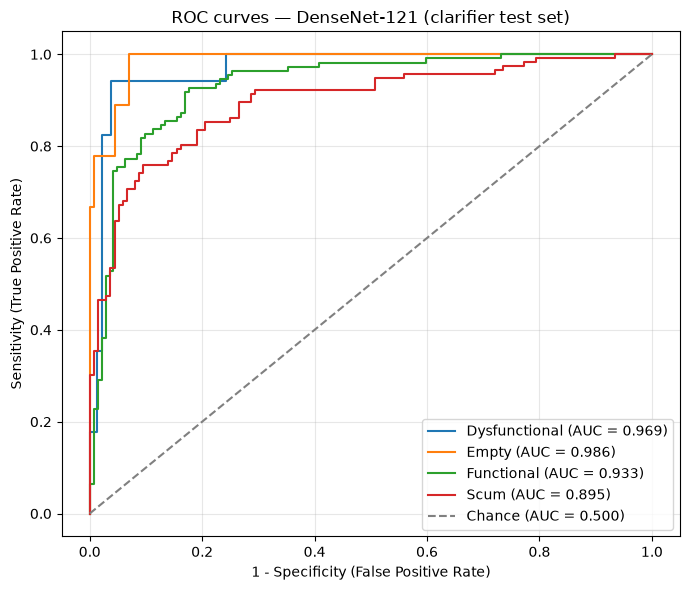

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.969
  Empty          : 0.986
  Functional     : 0.933
  Scum           : 0.895

Mean AUC (over 4/4 classes with test examples): 0.946


(np.float64(0.7936507936507936),
 {'Dysfunctional': 0.9689612015018774,
  'Empty': 0.9862825788751715,
  'Functional': 0.9327784891165173,
  'Scum': 0.8949670385395537})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/clarifier_aug/results_clarifier_densenet121_Fisantekraal.pkl
Saved model weights to ../models/clarifier_densenet121_cnn.pt
